<img src="./Imagenes/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos II

# Trabajo semanal 2
#### Alumno:    Lucas Gallero
#### Profesor:  Mariano Llamedo Soria  
#### Ayudante de TPs:    David Moharos
----

# Enunciado:

Se pide lo siguiente:

1. Establezca la función transferencia pasa bajos $T_{LPF}(s)$ mediante aproximación de máxima planicidad, por caso, Butterworth, de orden 6.

2. Obtenga respuesta de módulo, fase y diagrama de polos y ceros de forma cualitativa.

3. Implemente una red normalizada que responda a $T_{LPF}(s)$ mediante secciones de segundo orden (SOS) separadas por buffers.  
   En orden creciente de Q (Q1 < Q2 < Q3):

   - SOS_1: Sallen-Key
   - SOS_2: KHN
   - SOS_3: MFB

4. Indique las normas de frecuencia $\Omega_{\omega}$ e impedancia $\Omega_z$ adoptadas y los ajustes necesarios para obtener una ganancia de 10 dB en la banda de paso.

5. Verifique los resultados obtenidos analíticamente mediante simulaciones numéricas y/o simbólicas en Python y circuitales en LTSpice.

---

**Bonus:**

- +1 🧑‍🔬 Se pide implementar una función transferencia Butter pero de orden 7. ¿Puede reutilizar las SOSs obtenidas anteriormente? ¿Bastaría con cascadear una sección de primer orden?
- +1 🧑‍🔬 Indique qué modificaciones debería realizar y obtenga la red normalizada correspondiente.
- +1 💎 Verifique los resultados mediante simulaciones en Python y LTSpice.
- +1 🎓 Presentación en Jupyter Notebook.


In [17]:
# PyTC2: La librería para TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

from scipy.signal import TransferFunction
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sympy as sp
from sympy.abc import s
from IPython.display import display, Math
from scipy import signal
# las librerías que usarremos las cargamos solo una vez.


# Resolución


## 1) Transferencia de Filtro Pasa Bajos Butterwoorth de orden 6

### <ins>Desarrollo de la respuesta Butterworth

Para analizar la respuesta en frecuencia de un filtro, se parte de la función de transferencia evaluada en el eje imaginario, es decir:

$$
T(j\omega)
$$

Como esta función es compleja, puede escribirse separando su parte real e imaginaria:

$$
T(j\omega) = \text{Re}[T(j\omega)] + j\,\text{Im}[T(j\omega)]
$$

Si se reemplaza $j\omega$  por $-j\omega$, la parte real permanece igual, mientras que la parte imaginaria cambia de signo:

$$
T(-j\omega) = \text{Re}[T(j\omega)] - j\,\text{Im}[T(j\omega)]
$$

Por lo tanto, $T(-j\omega)$ corresponde al conjugado complejo de $T(j\omega)$:

$$
T(-j\omega) = T^*(j\omega)
$$

La magnitud al cuadrado de una función compleja se obtiene multiplicando dicha función por su conjugada:

$$
|T(j\omega)|^2 = T(j\omega) \cdot T^*(j\omega)
$$

Como $T^*(j\omega) = T(-j\omega)$, se obtiene:

$$
|T(j\omega)|^2 = T(j\omega) \cdot T(-j\omega)
$$

Esta relación permite expresar la magnitud al cuadrado de la función de transferencia a partir de la función evaluada en $j\omega$ y en $-j\omega$.

Luego se introduce una función característica $K(j\omega)$, que representa la desviación de la respuesta respecto del comportamiento ideal de un filtro pasa bajos. La magnitud al cuadrado se escribe como:

$$
|T_n(j\omega)|^2 = \frac{1}{1 + |K(j\omega)|^2}
$$

En esta expresión, cuando $K(j\omega)$ es pequeño, el denominador tiende a 1 y, por lo tanto, la magnitud del filtro se aproxima a la unidad. Esto ocurre en la banda de paso. En cambio, cuando $K(j\omega)$ aumenta, el denominador crece y la magnitud disminuye, produciendo la atenuación propia de la banda de rechazo.

Para obtener una respuesta Butterworth, se impone que la magnitud sea máximamente plana alrededor de $\omega = 0$. Esto significa que la respuesta no debe presentar ondulaciones en la banda de paso y que sus primeras variaciones deben ser nulas.

Se considera entonces que la magnitud al cuadrado de la función característica puede escribirse como un polinomio par de la frecuencia:

$$
|K(j\omega)|^2 = B_2\omega^2 + B_4\omega^4 + B_6\omega^6 + \cdots + B_{2n}\omega^{2n}
$$

Para que la respuesta sea máximamente plana, se anulan todos los coeficientes de menor orden:

$$
B_2 = B_4 = B_6 = \cdots = B_{2(n-1)} = 0
$$

De esta manera, solamente queda el término de mayor orden:

$$
|K(j\omega)|^2 = B_{2n}\omega^{2n}
$$

Definiendo:

$$
B_{2n} = \varepsilon^2
$$

se obtiene:

$$
|K(j\omega)|^2 = \varepsilon^2 \omega^{2n}
$$

Finalmente, reemplazando esta expresión en la ecuación general de la magnitud:

$$
|T_n(j\omega)|^2 = \frac{1}{1 + |K(j\omega)|^2}
$$

resulta:

$$
|T_n(j\omega)|^2 = \frac{1}{1 + \varepsilon^2 \omega^{2n}}
$$

Esta expresión corresponde a la respuesta en magnitud al cuadrado de un filtro Butterworth de orden $n$. Para el caso normalizado, se toma $\varepsilon^2 = 1$, por lo que queda:

$$
\boxed{|T_n(j\omega)|^2 = \frac{1}{1 + \omega^{2n}}}
$$

Esta es la forma clásica de la respuesta Butterworth normalizada, cuya principal característica es presentar una banda de paso máximamente plana y una pendiente de atenuación que aumenta con el orden del filtro.

### <ins>Obtención de la función transferencia Butterworth de orden 6

En este caso, el enunciado solicita obtener la función transferencia pasa bajos mediante una aproximación de máxima planicidad, es decir, una aproximación Butterworth de orden 6. Por lo tanto:

$$
n = 6
$$

Para un filtro Butterworth normalizado, la respuesta en magnitud al cuadrado está dada por:

$$
|T_n(j\omega)|^2 = \frac{1}{1+\omega^{2n}}
$$

Reemplazando $n = 6$:

$$
|T_6(j\omega)|^2 = \frac{1}{1+\omega^{12}}
$$

Esta expresión describe únicamente la magnitud al cuadrado del filtro. Para obtener la función transferencia en el dominio de Laplace, se utiliza la siguiente relación:

$$
|T(j\omega)|^2 = T(s)T(-s)
$$

Por lo tanto, para el caso Butterworth de orden 6:

$$
T_6(s)T_6(-s) = \frac{1}{1+\omega^{12}}
$$

Como se trabaja sobre el eje imaginario, se cumple que:

$$
s = j\omega
$$

de donde:

$$
\omega = \frac{s}{j}
$$

Entonces:

$$
\omega^{12} = \left(\frac{s}{j}\right)^{12}
$$

Como:

$$
j^{12} = 1
$$

resulta:

$$
\omega^{12} = s^{12}
$$

Por lo tanto:

$$
T_6(s)T_6(-s) = \frac{1}{1+s^{12}}
$$

Para encontrar los polos de la transferencia, se iguala a cero el denominador:

$$
1+s^{12}=0
$$

Luego:

$$
s^{12} = -1
$$

Esta ecuación posee doce raíces distribuidas sobre una circunferencia de radio unitario en el plano complejo. Sin embargo, para construir una función transferencia estable, se seleccionan únicamente las raíces ubicadas en el semiplano izquierdo, es decir, aquellas con parte real negativa.

Los ángulos absolutos de los polos estables, medidos desde el eje real positivo, pueden calcularse mediante:

$$
\boxed{\theta_k = \frac{\pi}{2} + \frac{(2k-1)\pi}{2n}}
$$

donde:

$$
k = 1,2,\dots,n
$$

Como en este caso $n = 6$:

$$
\theta_k = \frac{\pi}{2} + \frac{(2k-1)\pi}{12}
$$

Evaluando para $k = 1,2,\dots,6$, se obtiene:

$$
\theta_k = 105^\circ,\ 135^\circ,\ 165^\circ,\ 195^\circ,\ 225^\circ,\ 255^\circ
$$

Estos seis polos son los que pertenecen al semiplano izquierdo. De manera equivalente, si los ángulos se miden respecto del eje real negativo, se obtienen:

$$
\psi = \pm 15^\circ,\ \pm 45^\circ,\ \pm 75^\circ
$$

Esta forma es conveniente porque permite agrupar los polos complejos conjugados en tres pares. Cada par genera un factor cuadrático del denominador de la forma:

$$
s^2 + 2\cos(\psi)s + 1
$$

Por lo tanto, para el filtro Butterworth de orden 6 se obtienen tres factores de segundo orden.

Para $\psi = 75^\circ$:

$$
s^2 + 2\cos(75^\circ)s + 1
$$

Como:

$$
2\cos(75^\circ) = 0.5176
$$

queda:

$$
\boxed{s^2 + 0.5176s + 1}
$$

Para $\psi = 45^\circ$:

$$
s^2 + 2\cos(45^\circ)s + 1
$$

Como:

$$
2\cos(45^\circ) = 1.4142
$$

queda:

$$
\boxed{s^2 + 1.4142s + 1}
$$

Para $\psi = 15^\circ$:

$$
s^2 + 2\cos(15^\circ)s + 1
$$

Como:

$$
2\cos(15^\circ) = 1.9319
$$

queda:

$$
\boxed{s^2 + 1.9319s + 1}
$$

De esta manera, el polinomio Butterworth de sexto orden resulta:

$$
B_6(s) =
(s^2 + 0.5176s + 1)
(s^2 + 1.4142s + 1)
(s^2 + 1.9319s + 1)
$$

Como la aproximación Butterworth corresponde a un filtro de tipo `Todo-Polo`, la función transferencia pasa bajos normalizada se expresa como:

$$
T_{LPF}(s) = \frac{1}{B_6(s)}
$$

Por lo tanto:

$$
\boxed{T_{LPF}(s) =
\frac{1}
{(s^2 + 0.5176s + 1)
(s^2 + 1.4142s + 1)
(s^2 + 1.9319s + 1)}}
$$

Finalmente, desarrollando el producto de los factores cuadráticos, se obtiene:

$$
B_6(s) =
s^6 + 3.8637s^5 + 7.4641s^4 + 9.1416s^3 + 7.4641s^2 + 3.8637s + 1
$$

Por lo tanto, la función transferencia pasa bajos Butterworth normalizada de orden 6 queda:

$$
\boxed{T_{LPF}(s) =
\frac{1}
{s^6 + 3.8637s^5 + 7.4641s^4 + 9.1416s^3 + 7.4641s^2 + 3.8637s + 1}}
$$

Esta transferencia corresponde a una aproximación de máxima planicidad, ya que la respuesta Butterworth se caracteriza por no presentar ondulaciones en la banda de paso y por tener una atenuación que aumenta con el orden del filtro.

### <ins>Obtención mediante tabla de coeficientes normalizados

Otra forma más directa de obtener el polinomio Butterworth consiste en utilizar la tabla de coeficientes normalizados de los polinomios de Butterworth.

<div align="center">
    <img src="./Imagenes/Tabla_CoeficientesNormalizadosButterworth.png" alt="Tabla Coeficientes Normalizados" width="700"/>
</div>

El denominador normalizado puede expresarse de la forma:

$$
B_n(s) = a_0s^n + a_1s^{n-1} + a_2s^{n-2} + \cdots + a_{n-1}s + a_n
$$

Para los polinomios Butterworth normalizados se cumple que:

$$
a_0 = a_n = 1
$$

Como en este caso el filtro es de orden 6, se busca en la tabla la fila correspondiente a:

$$
n = 6
$$

De la tabla se obtienen los siguientes coeficientes:

$$
a_1 = 3.8637033
$$

$$
a_2 = 7.4641016
$$

$$
a_3 = 9.1416202
$$

$$
a_4 = 7.4641016
$$

$$
a_5 = 3.8637033
$$

Además, como $a_0 = a_6 = 1$, el polinomio Butterworth de sexto orden queda:

$$
B_6(s) =
s^6 + 3.8637033s^5 + 7.4641016s^4 + 9.1416202s^3 + 7.4641016s^2 + 3.8637033s + 1
$$

Finalmente:

$$
\boxed{T_{LPF}(s) =
\frac{1}
{s^6 + 3.8637033s^5 + 7.4641016s^4 + 9.1416202s^3 + 7.4641016s^2 + 3.8637033s + 1}}
$$

Tambien se puede obtener por tabla la forma factorizada

<div align="center">
    <img src="./Imagenes/DenominadorNormalizado_Factorizado.png" alt="Tabla denimonador normalizado" width="500"/>
</div>

$$
\boxed{T_{LPF}(s) =
\frac{1}
{(s^2 + 0.5176s + 1)
(s^2 + 1.4142s + 1)
(s^2 + 1.9319s + 1)}}
$$

De esta manera, la tabla permite obtener directamente el mismo resultado que se obtiene mediante la ubicación de los polos, pero de una forma más sencilla y rápida.

---


## 2) Respuesta de módulo, fase y diagrama de polos y ceros

A partir de la función transferencia pasa bajos Butterworth normalizada de orden 6:

$$
T_{LPF}(s) =
\frac{1}
{(s^2 + 0.5176s + 1)
(s^2 + 1.4142s + 1)
(s^2 + 1.9319s + 1)}
$$

se puede analizar cualitativamente su respuesta en frecuencia y su diagrama de polos y ceros.

#### <ins>Respuesta de módulo

Para un filtro Butterworth normalizado de orden $n$, la magnitud al cuadrado está dada por:

$$
|T_n(j\omega)|^2 = \frac{1}{1+\omega^{2n}}
$$

Como en este caso el filtro es de orden 6:

$$
n = 6
$$

entonces:

$$
|T_6(j\omega)|^2 = \frac{1}{1+\omega^{12}}
$$

Por lo tanto, la magnitud resulta:

$$
|T_6(j\omega)| = \frac{1}{\sqrt{1+\omega^{12}}}
$$

Para bajas frecuencias, es decir $\omega \ll 1$, el término $\omega^{12}$ tiende a cero. Por lo tanto:

$$
|T_6(j\omega)| \approx 1
$$

Esto indica que el filtro deja pasar las bajas frecuencias prácticamente sin atenuación.

En la frecuencia normalizada $\omega = 1$:

$$
|T_6(j1)| = \frac{1}{\sqrt{1+1^{12}}}
$$

$$
|T_6(j1)| = \frac{1}{\sqrt{2}} \approx 0.707
$$

Expresado en decibeles:

$$
20\log_{10}(0.707) \approx -3\,\text{dB}
$$

Por lo tanto, $\omega = 1$ corresponde a la frecuencia de corte normalizada del filtro.

Para altas frecuencias, es decir $\omega \gg 1$, la magnitud del filtro Butterworth de orden 6 puede aproximarse como:

$$
|T_6(j\omega)| =
\frac{1}{\sqrt{1+\omega^{12}}}
$$

Como para altas frecuencias se cumple que $\omega^{12} \gg 1$, entonces:

$$
1+\omega^{12} \approx \omega^{12}
$$

Por lo tanto:

$$
|T_6(j\omega)| \approx \frac{1}{\sqrt{\omega^{12}}}
$$

$$
|T_6(j\omega)| \approx \frac{1}{\omega^6}
$$

Expresando esta magnitud en decibeles:

$$
20\log_{10}|T_6(j\omega)|
=
20\log_{10}\left(\frac{1}{\omega^6}\right)
$$

$$
20\log_{10}|T_6(j\omega)|
=
20\log_{10}\left(\omega^{-6}\right)
$$

Aplicando propiedades logarítmicas:

$$
20\log_{10}|T_6(j\omega)|
=
-120\log_{10}(\omega)
$$

Esto significa que, por cada década de aumento en la frecuencia, la magnitud disminuye aproximadamente $120\,\text{dB}$. De forma general, en un filtro pasa bajos de orden $n$, cada polo aporta una pendiente de $-20\,\text{dB/década}$, por lo que la pendiente total es:

$$
-20n\ \text{dB/década}
$$

Para $n = 6$:

$$
-20 \cdot 6 = -120\ \text{dB/década}
$$

Por lo tanto, la respuesta de módulo se mantiene aproximadamente plana en $0\,\text{dB}$ para bajas frecuencias, cae $-3\,\text{dB}$ en $\omega = 1$ y luego decrece con una pendiente aproximada de $-120\,\text{dB/década}$.


<div align="center">
    <img src="./Imagenes/RespuestaModulo.png" alt="Enunciado" width="700"/>
</div>

#### <ins>Respuesta de fase

El filtro Butterworth de orden 6 posee seis polos y ningún cero finito. Cada polo aporta, para altas frecuencias, una variación de fase de aproximadamente $-90^\circ$.

Por lo tanto, la fase total para altas frecuencias tiende a:

$$
\varphi(\infty) = -6 \cdot 90^\circ
$$

$$
\varphi(\infty) = -540^\circ = -3\pi[rad]
$$

Para bajas frecuencias, la fase comienza aproximadamente en:

$$
\varphi(0) \approx 0^\circ
$$

A medida que aumenta la frecuencia, la fase comienza a disminuir. La transición principal ocurre alrededor de la frecuencia de corte normalizada $\omega = 1$. Finalmente, para frecuencias mucho mayores que la frecuencia de corte, la fase tiende asintóticamente a $-540^\circ = -3\pi[rad]$.

<div align="center">
    <img src="./Imagenes/RespuestaFase.png" alt="Enunciado" width="700"/>
</div>

#### <ins>Diagrama de polos y ceros

La aproximación Butterworth corresponde a un filtro de tipo `Todo-Polo`, es decir, un filtro que posee únicamente polos y no posee ceros finitos.

Por lo tanto:

$$
\text{ceros finitos} = 0
$$

Los polos de un Butterworth normalizado de orden 6 se ubican sobre una circunferencia de radio unitario en el semiplano izquierdo del plano $s$. Sus ángulos absolutos, medidos desde el eje real positivo, son:

$$
105^\circ,\ 135^\circ,\ 165^\circ,\ 195^\circ,\ 225^\circ,\ 255^\circ
$$

Partiendo de la transferencia factorizada se pueden despejar los polos facilmente:
$$
\boxed{T_{LPF}(s) =
\frac{1}
{(s^2 + 0.5176s + 1)
(s^2 + 1.4142s + 1)
(s^2 + 1.9319s + 1)}}
$$

$$
p_1 = -0.2588 + j0.9659
$$

$$
p_2 = -0.7071 + j0.7071
$$

$$
p_3 = -0.9659 + j0.2588
$$

$$
p_4 = -0.9659 - j0.2588
$$

$$
p_5 = -0.7071 - j0.7071
$$

$$
p_6 = -0.2588 - j0.9659
$$

Todos los polos tienen parte real negativa, por lo que el filtro resultante es estable.

El diagrama de polos y ceros presenta seis polos distribuidos simétricamente sobre una semicircunferencia de radio unitario en el semiplano izquierdo, y no presenta ceros finitos.

<div align="center">
    <img src="./Imagenes/Polos.png" alt="Enunciado" width="500"/>
</div>

---

## 3) Implementación normalizada mediante secciones de segundo orden

La transferencia pasa bajos Butterworth de orden 6 obtenida previamente es:

$$T_{LPF}(s)=\dfrac{1}{(s^2+0,5176s+1)(s^2+1,4142s+1)(s^2+1,9319s+1)}$$


Cada sección de segundo orden se compara con la forma general:

$T_{SOS}(s)=\dfrac{\omega_0^2}{s^2+\dfrac{\omega_0}{Q}s+\omega_0^2}$

Como se trabaja con la red normalizada:

$\omega_0=1\ \text{rad/s}$

Entonces:

$$\boxed{T_{SOS}(s)=\dfrac{1}{s^2+\dfrac{1}{Q}s+1}}$$

#### <ins>Cálculo de los factores de calidad

Comparando cada denominador de la transferencia con la forma normalizada:

$$
s^2+\dfrac{1}{Q}s+1
$$

se obtienen los valores de $Q$.

Para el primer factor:

$$
s^2+1,9319s+1
$$

$$
\dfrac{1}{Q_1}=1,9319
$$

$$
Q_1=\dfrac{1}{1,9319}
$$

$$
\boxed{Q_1=0,5176}
$$

Para el segundo factor:

$$
s^2+1,4142s+1
$$

$$
\dfrac{1}{Q_2}=1,4142
$$

$$
Q_2=\dfrac{1}{1,4142}
$$

$$
\boxed{Q_2=0,7071}
$$

Para el tercer factor:

$$
s^2+0,5176s+1
$$

$$
\dfrac{1}{Q_3}=0,5176
$$

$$
Q_3=\dfrac{1}{0,5176}
$$

$$
\boxed{Q_3=1,9319}
$$

#### <ins>Asignación de las secciones

El enunciado pide implementar las secciones de segundo orden en orden creciente de $Q$: $Q_1<Q_2<Q_3$

Por lo tanto, se asignan las configuraciones de la siguiente manera:

| Sección | Configuración | Factor asociado | $Q$ |
|---|---|---|---|
| SOS 1 | Sallen-Key | $s^2+1,9319s+1$ | $0,5176$ |
| SOS 2 | KHN | $s^2+1,4142s+1$ | $0,7071$ |
| SOS 3 | MFB | $s^2+0,5176s+1$ | $1,9319$ |

La transferencia total queda implementada como el producto de las tres secciones:

$$\boxed{T_{LPF}(s)=T_{SOS1}(s)\cdot T_{SOS2}(s)\cdot T_{SOS3}(s)}$$

---

### <ins>SOS 1: Sallen-Key pasa bajos

<div align="center">
    <img src="./Imagenes/SallenKey.png" alt="SallenKey PasaBajos" width="450"/>
</div>

Para implementar la primera sección del filtro se utiliza una red Sallen-Key pasa bajos. La transferencia general de esta configuración puede escribirse como:

$$
\boxed{
T_{SOS1}(s)=K\dfrac{\dfrac{1}{R_1R_2C_1C_2}}{s^2+s\left[\dfrac{1}{R_1C_1}+\dfrac{1}{R_2C_1}+\dfrac{1-K}{R_2C_2}\right]+\dfrac{1}{R_1R_2C_1C_2}}
}
$$

Para simplificar el diseño se adoptan resistencias y capacitores iguales:

$$
R_1=R_2=R
$$

$$
C_1=C_2=C
$$

Con estas condiciones, la transferencia queda:

$$
\boxed{
T_{SOS1}(s)=K\dfrac{\left(\dfrac{1}{RC}\right)^2}{s^2+s\left(\dfrac{3-K}{RC}\right)+\left(\dfrac{1}{RC}\right)^2}
}
$$

La frecuencia natural de la sección se obtiene a partir del término independiente del denominador:

$$
\omega_0^2=\left(\dfrac{1}{RC}\right)^2
$$

$$
\omega_0=\dfrac{1}{RC}
$$

Como se trabaja con un prototipo Butterworth normalizado, se adopta:

$$
\Omega_\omega=\omega_0=1\ \text{rad/s}
$$

y como norma de impedancia:

$$
\Omega_z=R
$$

De esta manera, las variables normalizadas resultan:

$$
R_N=\dfrac{R}{\Omega_z}=1
$$

$$
C_N=C\cdot\Omega_z\cdot\Omega_\omega
$$

$$
C_N=C\cdot R\cdot\dfrac{1}{RC}=1
$$

Por lo tanto, para la red normalizada:

$$
\boxed{R_1=R_2=1}
$$

$$
\boxed{C_1=C_2=1}
$$

Reemplazando en la transferencia:

$$
\boxed{
T_{SOS1}(s)=K\dfrac{1}{s^2+s(3-K)+1}
}
$$

La forma canónica normalizada de segundo orden es:

$$
T_{SOS}(s)=\dfrac{1}{s^2+\dfrac{1}{Q}s+1}
$$

Comparando denominadores:

$$
3-K=\dfrac{1}{Q}
$$

El factor de segundo orden correspondiente al SOS 1 es:

$$
s^2+1,9319s+1
$$

Por comparación con:

$$
s^2+\dfrac{1}{Q}s+1
$$

se obtiene:

$$
Q=\dfrac{1}{1,9319}
$$

$$
Q=0,5176
$$

Entonces:

$$
K=3-\dfrac{1}{Q}
$$

$$
K=3-\dfrac{1}{0,5176}
$$

$$
\boxed{K=1,068}
$$

La ganancia del Sallen-Key se implementa mediante la relación resistiva:

$$
K=1+\dfrac{R_4}{R_3}
$$

Entonces:

$$
\dfrac{R_4}{R_3}=K-1
$$

$$
\dfrac{R_4}{R_3}=1,068-1
$$

$$
\boxed{\dfrac{R_4}{R_3}=0,068}
$$

Adoptando:

$$
\boxed{R_3=1}
$$

se obtiene:

$$
\boxed{R_4=0,068}
$$

La configuración Sallen-Key diseñada introduce una ganancia:

$$
K=1,068
$$

En decibeles:

$$
K_{dB}=20\log_{10}(1,068)
$$

$$
K_{dB}=0,57\ dB
$$

Como la transferencia Butterworth normalizada debe tener ganancia unitaria en continua, esta ganancia adicional se compensa mediante un divisor resistivo.

<div align="center">
    <img src="./Imagenes/DivisorResistivo.png" alt="Divisor Resistivo" width="300"/>
</div>

La atenuación necesaria es:

$$
A=\dfrac{1}{K}
$$

$$
A=\dfrac{1}{1,068}
$$

$$
\boxed{A=0,936}
$$

Para un divisor resistivo:

$$
A=\dfrac{R_b}{R_a+R_b}
$$

Adoptando:

$$
\boxed{R_b=1}
$$

se despeja:

$$
R_a=R_b\dfrac{1-A}{A}
$$

$$
R_a=\dfrac{1-0,936}{0,936}
$$

$$
\boxed{R_a\approx 0,068}
$$

Entonces, el divisor resistivo queda:

$$
\boxed{R_a=0,068}
$$

$$
\boxed{R_b=1}
$$

Finalmente, la sección Sallen-Key implementa el primer factor de la transferencia Butterworth:

$$
\boxed{
T_{SOS1}(s)=\dfrac{1}{s^2+1,9319s+1}
}
$$

---

### <ins>SOS 2: KHN pasa bajos

<div align="center">
    <img src="./Imagenes/KHN.png" alt="KHN PasaBajos" width="700"/>
</div>

Para implementar la segunda sección del filtro se utiliza una red KHN pasa bajos. La transferencia general utilizada es:

$$
\boxed{
T_{SOS2}(s)=
-\dfrac{
\dfrac{R_1}{C_1C_2R_1R_2R_3}
}{
s^2+
s\left[
\dfrac{1}{K}
\left(
\dfrac{3}{C_1R_4}
\left(
\dfrac{1}{R_1}+\dfrac{1}{R_2}+\dfrac{1}{R_3}
\right)
\right)
\right]
+
\dfrac{R_3}{C_1C_2R_1R_2R_5}
}}
$$

Se adoptan resistencias y capacitores iguales para simplificar el diseño:

$$
R_1=R_2=R_3=R_4=R_5=R
$$

$$
C_1=C_2=C
$$

Con estas condiciones, la transferencia queda:

$$
\boxed{
T_{SOS2}(s)=
-\dfrac{
\left(\dfrac{1}{RC}\right)^2
}{
s^2+
s\left[
\dfrac{3}{K}
\left(\dfrac{1}{RC}\right)
\right]
+
\left(\dfrac{1}{RC}\right)^2
}}
$$

La frecuencia natural de la sección es:

$$
\omega_0=\dfrac{1}{RC}
$$

Como se trabaja con un prototipo normalizado, se adopta:

$$
\Omega_\omega=\omega_0=1\ \text{rad/s}
$$

y como norma de impedancia:

$$
\Omega_z=R
$$

De esta manera, las variables normalizadas resultan:

$$
R_N=\dfrac{R}{\Omega_z}=1
$$

$$
C_N=C\cdot\Omega_z\cdot\Omega_\omega
$$

$$
C_N=C\cdot R\cdot\dfrac{1}{RC}=1
$$

Por lo tanto, para la red normalizada:

$$
R_1=R_2=R_3=R_4=R_5=1
$$

$$
C_1=C_2=1
$$

Reemplazando en la transferencia:

$$
\boxed{
T_{SOS2}(s)=
-\dfrac{1}{s^2+s\dfrac{3}{K}+1}}
$$

La forma canónica normalizada de segundo orden es:

$$
T_{SOS}(s)=\dfrac{1}{s^2+\dfrac{1}{Q}s+1}
$$

Comparando denominadores:

$$
\dfrac{1}{Q}=\dfrac{3}{K}
$$

$$
Q=\dfrac{K}{3}
$$

En la red KHN, el parámetro $K$ se implementa mediante la relación resistiva:

$$
K=\dfrac{R_6+R_7}{R_7}
$$

$$
K=1+\dfrac{R_6}{R_7}
$$

Entonces:

$$
Q=\dfrac{1}{3}\left(1+\dfrac{R_6}{R_7}\right)
$$

$$
Q=\dfrac{R_6+R_7}{3R_7}
$$

Adoptando:

$$
\boxed{R_7=1}
$$

queda:

$$
Q=\dfrac{R_6+1}{3}
$$

El factor de segundo orden correspondiente al SOS 2 es:

$$
s^2+1,4142s+1
$$

Por comparación con:

$$
s^2+\dfrac{1}{Q}s+1
$$

se obtiene:

$$
Q=\dfrac{1}{1,4142}=0,7071
$$

Finalmente:

$$
R_6=3Q-1
$$

$$
R_6=3\cdot0,7071-1
$$

$$
\boxed{R_6=1,121}
$$

Con estos valores, la sección KHN implementa el segundo factor de la transferencia Butterworth:

$$
\boxed{
T_{SOS2}(s)=
-\dfrac{1}{s^2+1,4142s+1}}
$$

El signo negativo corresponde a la inversión propia de la configuración utilizada.

---

### <ins>SOS 3: MFB pasa bajos

<div align="center">
    <img src="./Imagenes/MFB.png" alt="MFB PasaBajos" width="400"/>
</div>

Para implementar la tercera sección del filtro se utiliza una red MFB pasa bajos, ya que esta configuración permite obtener valores de $Q$ elevados. La transferencia general utilizada es:

$$
\boxed{
T_{SOS3}(s)=
-\dfrac{
\dfrac{R_3}{R_1R_2R_3C_1C_2}
}{
s^2+
s\dfrac{1}{C_1}
\left(
\dfrac{1}{R_1}+\dfrac{1}{R_2}+\dfrac{1}{R_3}
\right)
+
\dfrac{1}{R_2R_3C_1C_2}
}}
$$

La frecuencia natural y el factor de calidad de esta red se obtienen comparando el denominador con la forma canónica:

$$
T_{SOS}(s)=\dfrac{\omega_0^2}{s^2+\dfrac{\omega_0}{Q}s+\omega_0^2}
$$

Por comparación:

$$
\omega_0^2=\dfrac{1}{R_2R_3C_1C_2}
$$

$$
\omega_0=\dfrac{1}{\sqrt{R_2R_3C_1C_2}}
$$

y:

$$
\dfrac{\omega_0}{Q}=
\dfrac{1}{C_1}
\left(
\dfrac{1}{R_1}+\dfrac{1}{R_2}+\dfrac{1}{R_3}
\right)
$$

Por lo tanto:

$$
Q=
\dfrac{
\sqrt{R_2R_3C_1C_2}
}{
R_2R_3C_2
\left(
\dfrac{1}{R_1}+\dfrac{1}{R_2}+\dfrac{1}{R_3}
\right)
}
$$

Inicialmente, si se adoptan resistencias iguales y capacitores iguales:

$$
R_1=R_2=R_3=R
$$

$$
C_1=C_2=C
$$

el factor de calidad queda:

$$
Q=\dfrac{1}{3}
$$

Este valor no alcanza el requerido para la tercera sección, ya que el factor de segundo orden asociado al SOS 3 es:

$$
s^2+0,5176s+1
$$

Comparando con:

$$
s^2+\dfrac{1}{Q}s+1
$$

se obtiene:

$$
Q=\dfrac{1}{0,5176}
$$

$$
\boxed{Q=1,9319}
$$

Como $Q=1,9319$ es mucho mayor que $1/3$, no se puede utilizar la condición $C_1=C_2$ manteniendo resistencias iguales.

Por este motivo se mantiene:

$$
R_1=R_2=R_3=R
$$

pero se adopta:

$$
C_1\neq C_2
$$

Bajo esta condición, el factor de calidad queda:

$$
Q=\dfrac{1}{3}\sqrt{\dfrac{C_1}{C_2}}
$$

Despejando la relación entre capacitores:

$$
3Q=\sqrt{\dfrac{C_1}{C_2}}
$$

$$
(3Q)^2=\dfrac{C_1}{C_2}
$$

$$
\dfrac{C_1}{C_2}=9Q^2
$$

Reemplazando:

$$
\dfrac{C_1}{C_2}=9(1,9319)^2
$$

$$
\boxed{\dfrac{C_1}{C_2}=33,59}
$$

Por lo tanto:

$$
C_1=33,59C_2
$$

Para normalizar la sección se adopta:

$$
\Omega_\omega=\omega_0=1\ \text{rad/s}
$$

y como norma de impedancia:

$$
\Omega_z=R
$$

Trabajando con resistencias normalizadas:

$$
R_1=R_2=R_3=1
$$

La frecuencia natural queda:

$$
\omega_0^2=\dfrac{1}{R^2C_1C_2}
$$

Como:

$$
\omega_0=1
$$

entonces:

$$
1=\dfrac{1}{R^2C_1C_2}
$$

Adoptando:

$$
R=1
$$

queda:

$$
C_1C_2=1
$$

Ahora se tienen dos condiciones:

$$
\dfrac{C_1}{C_2}=33,59
$$

$$
C_1C_2=1
$$

De la primera condición:

$$
C_1=33,59C_2
$$

Reemplazando en la segunda:

$$
33,59C_2^2=1
$$

$$
C_2^2=\dfrac{1}{33,59}
$$

$$
C_2=\sqrt{\dfrac{1}{33,59}}
$$

$$
\boxed{C_2=0,1725}
$$

Luego:

$$
C_1=33,59\cdot0,1725
$$

$$
\boxed{C_1=5,795}
$$

Por lo tanto, los valores normalizados adoptados para la sección MFB son:

$$
\boxed{R_1=R_2=R_3=1}
$$

$$
\boxed{C_1=5,795}
$$

$$
\boxed{C_2=0,1725}
$$

Con estos valores, la sección MFB implementa el tercer factor de la transferencia Butterworth:

$$
\boxed{
T_{SOS3}(s)=
-\dfrac{1}{s^2+0,5176s+1}
}
$$

El signo negativo corresponde a la inversión propia de la configuración MFB utilizada. En módulo, la sección implementa correctamente el factor requerido.

----

## 4) Normas adoptadas y ajuste de ganancia

### <ins>Normas adoptadas 

Para el diseño de las secciones de segundo orden se trabaja a partir de un prototipo Butterworth normalizado. Por este motivo, se adopta como norma de frecuencia:

$$
\boxed{\Omega_\omega=\omega_0}
$$

Como la frecuencia natural de las secciones está dada por:

$$
\omega_0=\dfrac{1}{RC}
$$

entonces:

$$
\Omega_\omega=\dfrac{1}{RC}
$$

Además, se adopta como norma de impedancia:

$$
\boxed{\Omega_z=R}
$$

Con estas normas, la resistencia normalizada queda:

$$
R_N=\dfrac{R}{\Omega_z}
$$

Reemplazando:

$$
R_N=\dfrac{R}{R}
$$

$$
\boxed{R_N=1}
$$

La capacidad normalizada se obtiene como:

$$
C_N=C\cdot\Omega_z\cdot\Omega_\omega
$$

Reemplazando las normas adoptadas:

$$
C_N=C\cdot R\cdot\dfrac{1}{RC}
$$

$$
\boxed{C_N=1}
$$

Por lo tanto, al adoptar:

$$
\boxed{\Omega_z=R}
$$

$$
\boxed{\Omega_\omega=\dfrac{1}{RC}}
$$

las secciones quedan normalizadas con:

$$
\boxed{R_N=1}
$$

$$
\boxed{C_N=1}
$$

Esta elección permite expresar las transferencias de las secciones en función de valores normalizados, manteniendo la frecuencia natural en:

$$
\boxed{\omega_0=1\ \text{rad/s}}
$$

### <ins>Ajuste de ganancia en banda de paso

La transferencia Butterworth normalizada obtenida tiene ganancia unitaria en continua:

$$
T_{LPF}(0)=1
$$

Por lo tanto:

$$
20\log_{10}\left(T_{LPF}(0)\right)=20\log_{10}(1)
$$

$$
T_{LPF}(0)=0\ \text{dB}
$$

El enunciado solicita una ganancia de:

$$
10\ \text{dB}
$$

Para convertir esta ganancia a escala lineal:

$$
K=10^{\frac{10}{20}}
$$

$$
\boxed{K=3,162}
$$

Entonces, la nueva transferencia con ganancia en banda de paso queda:

$$
\boxed{
T'_{LPF}(s)=
\dfrac{3,162}
{(s^2+1,9319s+1)(s^2+1,4142s+1)(s^2+0,5176s+1)}
}
$$


### <ins>Implementación de la ganancia de 10 dB

Para obtener la ganancia solicitada se agrega una etapa amplificadora no inversora al final del filtro.

<div align="center">
    <img src="./Imagenes/OpAmp_NoInversor.png" alt="OpAmp No Inversor" width="300"/>
</div>

La ganancia de un amplificador no inversor está dada por:

$$
K=1+\dfrac{R_f}{R_g}
$$

Como se necesita:

$$
K=3,162
$$

entonces:

$$
3,162=1+\dfrac{R_f}{R_g}
$$

Despejando:

$$
\dfrac{R_f}{R_g}=3,162-1
$$

$$
\boxed{\dfrac{R_f}{R_g}=2,162}
$$

Adoptando:

$$
\boxed{R_g=1}
$$

se obtiene:

$$
\boxed{R_f=2,162}
$$

Por lo tanto, la etapa final de ganancia queda definida por:

$$
\boxed{
K=1+\dfrac{2,162}{1}=3,162
}
$$

equivalente a:

$$
\boxed{10\ \text{dB}}
$$

---

## 5) Verificación por Simulacón

1) <ins>Transferencia Pasa Bajos Butterworth Orden 6

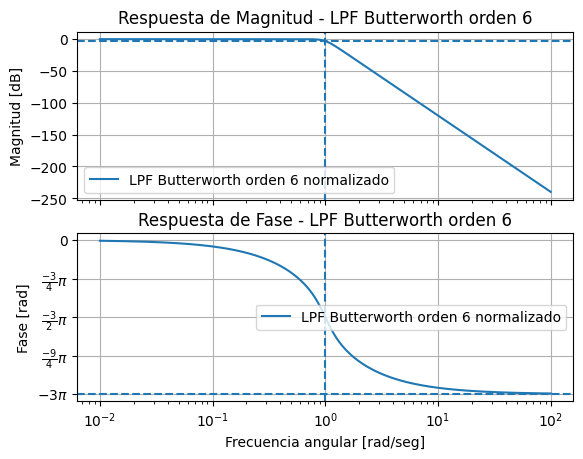

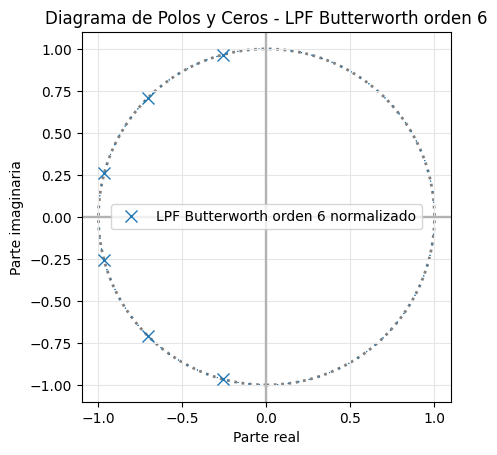

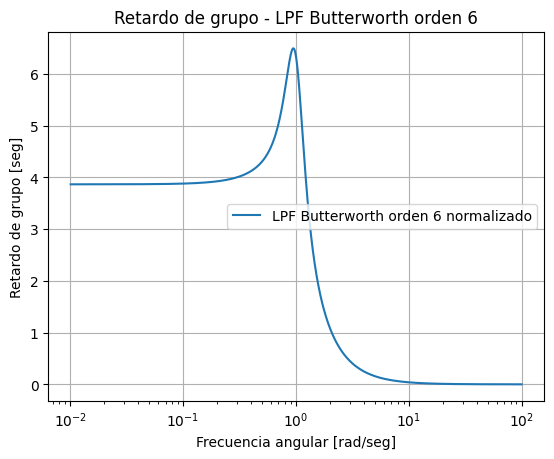

Verificaciones:
w =      0 rad/s
  |T(jw)|     = 1.000000
  |T(jw)| dB  = 0.000 dB
  fase        = 0.000000 rad

w =      1 rad/s
  |T(jw)|     = 0.707148
  |T(jw)| dB  = -3.010 dB
  fase        = 1.570796 rad

w =     10 rad/s
  |T(jw)|     = 0.000001
  |T(jw)| dB  = -120.000 dB
  fase        = -2.754749 rad

w =    100 rad/s
  |T(jw)|     = 0.000000
  |T(jw)| dB  = -240.000 dB
  fase        = -3.102955 rad

Denominador total:
[1.         3.8637     7.46403434 9.14153133 7.46403434 3.8637
 1.        ]

Polos:
(-0.25879999999999853+0.9659309292076733j)
(-0.25879999999999853-0.9659309292076733j)
(-0.9659499999999974+0.2587288107266019j)
(-0.9659499999999974-0.2587288107266019j)
(-0.7071000000000046+0.7071135623080653j)
(-0.7071000000000046-0.7071135623080653j)


In [5]:
# ------------------------------------------------------------
# Transferencia Butterworth pasa bajos normalizada de orden 6
# T(s) = 1 / [(s^2 + 0.5176s + 1)(s^2 + 1.4142s + 1)(s^2 + 1.9319s + 1)]
# ------------------------------------------------------------

# ------------------------------------------------------------
# Transferencia normalizada Butterworth pasa bajos de orden 6
#
# T_LPF(s) = 1 / [(s^2 + 0.5176s + 1)
#                 (s^2 + 1.4142s + 1)
#                 (s^2 + 1.9319s + 1)]
# ------------------------------------------------------------

# Denominadores de cada sección de segundo orden
den_sos1 = [1, 0.5176, 1]
den_sos2 = [1, 1.4142, 1]
den_sos3 = [1, 1.9319, 1]

# Denominador total del filtro
den_total = np.polymul(np.polymul(den_sos1, den_sos2), den_sos3)

# Numerador total
num_total = [1]

# Función transferencia total
my_tf = TransferFunction(num_total, den_total)

# ------------------------------------------------------------
# Respuesta de Magnitud y Fase
# ------------------------------------------------------------

bodePlot(my_tf, fig_id=1, filter_description='LPF Butterworth orden 6 normalizado')

fig1 = plt.figure(1)
axs1 = fig1.axes

axs1[0].set_title('Respuesta de Magnitud - LPF Butterworth orden 6')
axs1[1].set_title('Respuesta de Fase - LPF Butterworth orden 6')

axs1[0].set_ylabel('Magnitud [dB]')
axs1[1].set_ylabel('Fase [rad]')
axs1[1].set_xlabel('Frecuencia angular [rad/seg]')

# Líneas de referencia
axs1[0].axvline(1, linestyle='--')
axs1[0].axhline(-3, linestyle='--')

axs1[1].axvline(1, linestyle='--')
axs1[1].axhline(-3*np.pi, linestyle='--')

# ------------------------------------------------------------
# Diagrama de Polos y Ceros
# ------------------------------------------------------------

pzmap(my_tf, fig_id=2, filter_description='LPF Butterworth orden 6 normalizado')

fig2 = plt.figure(2)
axs2 = fig2.axes

fig2._suptitle.set_text('')
axs2[0].set_title('Diagrama de Polos y Ceros - LPF Butterworth orden 6')
axs2[0].set_xlabel('Parte real')
axs2[0].set_ylabel('Parte imaginaria')

# ------------------------------------------------------------
# Retardo de Grupo
# ------------------------------------------------------------

GroupDelay(my_tf, fig_id=3, filter_description='LPF Butterworth orden 6 normalizado')

fig3 = plt.figure(3)
axs3 = fig3.axes

axs3[0].set_title('Retardo de grupo - LPF Butterworth orden 6')
axs3[0].set_xlabel('Frecuencia angular [rad/seg]')
axs3[0].set_ylabel('Retardo de grupo [seg]')

plt.show()

# ------------------------------------------------------------
# Verificaciones numéricas puntuales
# ------------------------------------------------------------

# Evaluar en w = 0, w = 1 y w grande
w_test = np.array([0, 1, 10, 100])
_, H_test = signal.freqs(num, den, w_test)

print("Verificaciones:")
for wi, Hi in zip(w_test, H_test):
    print(f"w = {wi:>6} rad/s")
    print(f"  |T(jw)|     = {abs(Hi):.6f}")
    print(f"  |T(jw)| dB  = {20*np.log10(abs(Hi)):.3f} dB")
    print(f"  fase        = {np.angle(Hi):.6f} rad")
    print()

print("Denominador total:")
print(den)

print("\nPolos:")
for p in polos:
    print(p)

2) <ins>SOS 1 Sallen-Key Pasa Bajos

In [19]:
# Variable compleja
s = sp.symbols("s")

# Tensiones
Vi, VA, Vx, Vo = sp.symbols("Vi VA Vx Vo")

# Componentes
R1, R2, C1, C2 = sp.symbols("R1 R2 C1 C2", positive=True)

# Constante de realimentación
K1 = sp.symbols("K_1", positive=True)

# Admitancias
G1 = 1/R1
G2 = 1/R2

# Sistema de ecuaciones por nodos
sistema = sp.solve([

    # Nodo A:
    # VA(G1+G2+sC2) - Vi*G1 - Vx*G2 - Vo*sC2 = 0
    VA*(G1 + G2 + s*C2) - Vi*G1 - Vx*G2 - Vo*s*C2,

    # Nodo B:
    # Vx(G2+sC1) - VA*G2 = 0
    Vx*(G2 + s*C1) - VA*G2,

    # Nodo C:
    # Vx = Vo/K1
    Vx - Vo/K1

], [Vi, VA, Vx], dict=True)[0]

# Transferencia Vo / Vi
tf = sp.factor(sp.simplify(Vo / sistema[Vi]))

# Separar numerador y denominador
num, den = sp.fraction(tf)

num = sp.expand(num)
den = sp.expand(den)

# Coeficiente del término de mayor grado del denominador
coef_mayor = sp.Poly(den, s).LC()

# Normalizar para que el coeficiente de mayor grado sea 1
num_monic = sp.simplify(num / coef_mayor)
den_monic = sp.collect(sp.simplify(den / coef_mayor), s)

# Mostrar transferencia original
display(Math(
    r"T(s)=\frac{V_o}{V_i}="
    + sp.latex(tf)
))

# Mostrar transferencia normalizada
display(Math(
    r"T(s)="
    + r"\frac{" + sp.latex(num_monic) + r"}{"
    + sp.latex(den_monic) + r"}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Text(0, 0.5, 'Retardo de grupo [seg]')

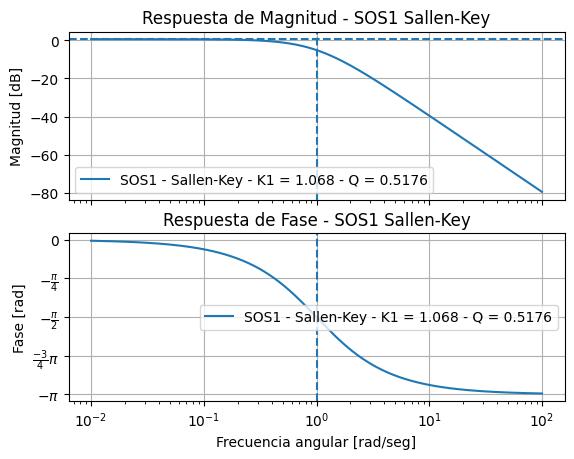

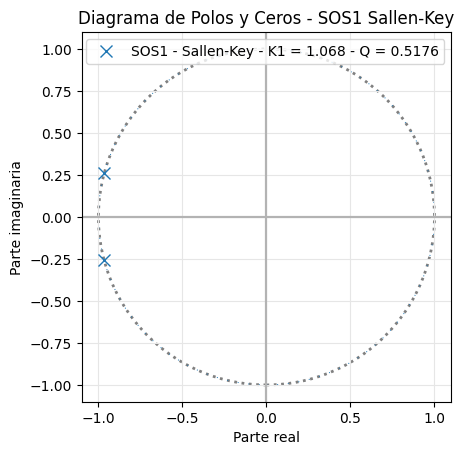

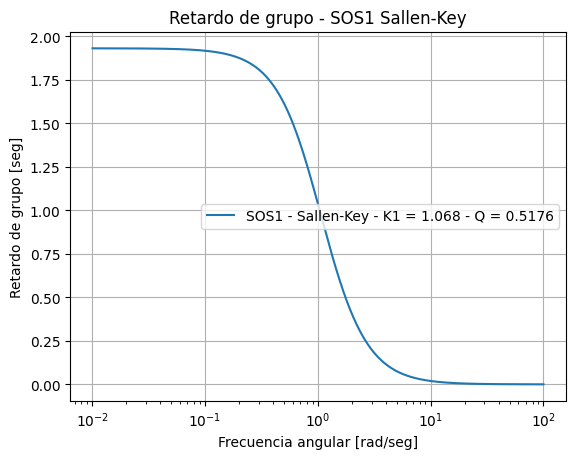

In [14]:
# ------------------------------------------------------------
# SOS1 - Sallen-Key
#
# T_SOS1(s) = K1 / (s^2 + 1.9319s + 1)
# Q1 = 1 / 1.9319 = 0.5176
# ------------------------------------------------------------
K1 = 1.068
num_sos1 = [K1]
den_sos1 = [1, 1.9319, 1]

sos1_tf = TransferFunction(num_sos1, den_sos1)

bodePlot(sos1_tf, fig_id=1, filter_description='SOS1 - Sallen-Key - K1 = 1.068 - Q = 0.5176')

fig1 = plt.figure(1)
axs1 = fig1.axes


axs1[0].set_title('Respuesta de Magnitud - SOS1 Sallen-Key')
axs1[1].set_title('Respuesta de Fase - SOS1 Sallen-Key')
axs1[0].set_ylabel('Magnitud [dB]')
axs1[1].set_ylabel('Fase [rad]')
axs1[1].set_xlabel('Frecuencia angular [rad/seg]')

axs1[0].axvline(1, linestyle='--')
axs1[0].axhline(20*np.log10(K1), linestyle='--')

axs1[1].axvline(1, linestyle='--')


pzmap(sos1_tf, fig_id=2, filter_description='SOS1 - Sallen-Key - K1 = 1.068 - Q = 0.5176')

fig2 = plt.figure(2)
axs2 = fig2.axes

fig2._suptitle.set_text('')
axs2[0].set_title('Diagrama de Polos y Ceros - SOS1 Sallen-Key')
axs2[0].set_xlabel('Parte real')
axs2[0].set_ylabel('Parte imaginaria')


GroupDelay(sos1_tf, fig_id=3, filter_description='SOS1 - Sallen-Key - K1 = 1.068 - Q = 0.5176')

fig3 = plt.figure(3)
axs3 = fig3.axes

axs3[0].set_title('Retardo de grupo - SOS1 Sallen-Key')
axs3[0].set_xlabel('Frecuencia angular [rad/seg]')
axs3[0].set_ylabel('Retardo de grupo [seg]')


3) <ins>SOS 2: KHN Pasa Bajos

In [11]:
import sympy as sp
from IPython.display import display, Math

# Variable compleja
s = sp.symbols("s")

# Tensiones
Vi, Vx, Vo, VH, VB = sp.symbols("Vi Vx Vo VH VB")

# Componentes
R1, R2, R3, R4, R5, R6, R7, C1, C2 = sp.symbols(
    "R1 R2 R3 R4 R5 R6 R7 C1 C2", positive=True
)

# Admitancias
G1 = 1/R1
G2 = 1/R2
G3 = 1/R3
G4 = 1/R4
G5 = 1/R5
G6 = 1/R6
G7 = 1/R7

# Sistema de ecuaciones por nodos
sistema = sp.solve([

    # NODO A:
    # Vx(G1+G2+G3)-Vi*G1-Vo*G2-VH*G3=0
    Vx*(G1 + G2 + G3) - Vi*G1 - Vo*G2 - VH*G3,

    # NODO B:
    # Vx(G6+G7)-VB*G6 = 0
    Vx*(G6 + G7) - VB*G6,

    # NODO C:
    # VH*G4 + VB*sC1 = 0
    VH*G4 + VB*s*C1,

    # NODO D:
    # VB*G5 + Vo*sC2 = 0
    VB*G5 + Vo*s*C2

], [Vi, Vx, VH, VB], dict=True)[0]

# Transferencia Vo / Vi
tf = sp.factor(sp.simplify(Vo / sistema[Vi]))

# Separar numerador y denominador
num, den = sp.fraction(tf)

num = sp.expand(num)
den = sp.expand(den)

# Coeficiente del término de mayor grado del denominador
coef_mayor = sp.Poly(den, s).LC()

# Normalizar para que el coeficiente de mayor grado sea 1
num_monic = sp.simplify(num / coef_mayor)
den_norm = sp.simplify(den / coef_mayor)

# Separar coeficientes del denominador
poly_den = sp.Poly(sp.expand(den_norm), s)

a2 = sp.simplify(poly_den.coeff_monomial(s**2))
a1 = sp.simplify(poly_den.coeff_monomial(s))
a0 = sp.simplify(poly_den.coeff_monomial(1))

# Armar denominador ordenado
den_monic = s**2 + a1*s + a0

# Mostrar transferencia original
display(Math(
    r"T(s)=\frac{V_o}{V_i}="
    + sp.latex(tf)
))

# Mostrar transferencia normalizada
display(Math(
    r"T(s)="
    + r"\frac{" + sp.latex(num_monic) + r"}{"
    + sp.latex(den_monic) + r"}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Text(0, 0.5, 'Retardo de grupo [seg]')

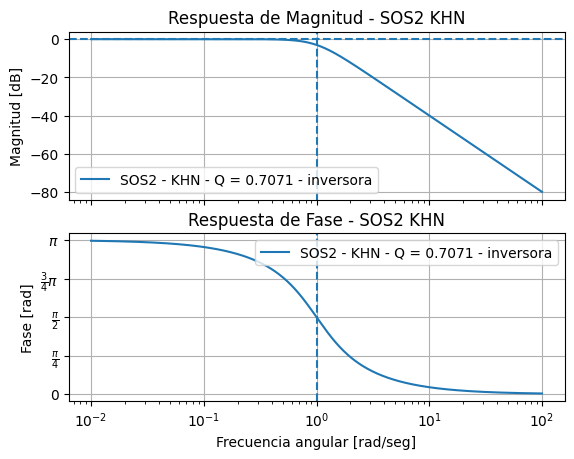

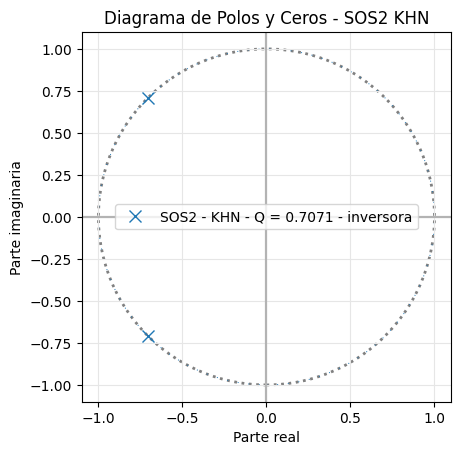

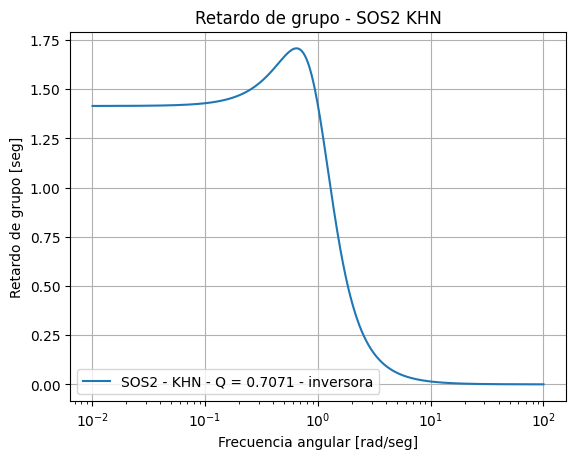

In [15]:
# ------------------------------------------------------------
# SOS2 - KHN
#
# T_SOS2(s) = -1 / (s^2 + 1.4142s + 1)
# Q2 = 1 / 1.4142 = 0.7071
# ------------------------------------------------------------

num_sos2 = [-1]
den_sos2 = [1, 1.4142, 1]

sos2_tf = TransferFunction(num_sos2, den_sos2)

bodePlot(sos2_tf, fig_id=4, filter_description='SOS2 - KHN - Q = 0.7071 - inversora')

fig4 = plt.figure(4)
axs4 = fig4.axes

axs4[0].set_title('Respuesta de Magnitud - SOS2 KHN')
axs4[1].set_title('Respuesta de Fase - SOS2 KHN')
axs4[0].set_ylabel('Magnitud [dB]')
axs4[1].set_ylabel('Fase [rad]')
axs4[1].set_xlabel('Frecuencia angular [rad/seg]')

axs4[0].axvline(1, linestyle='--')
axs4[0].axhline(0, linestyle='--')
axs4[1].axvline(1, linestyle='--')


pzmap(sos2_tf, fig_id=5, filter_description='SOS2 - KHN - Q = 0.7071 - inversora')

fig5 = plt.figure(5)
axs5 = fig5.axes

fig5._suptitle.set_text('')
axs5[0].set_title('Diagrama de Polos y Ceros - SOS2 KHN')
axs5[0].set_xlabel('Parte real')
axs5[0].set_ylabel('Parte imaginaria')


GroupDelay(sos2_tf, fig_id=6, filter_description='SOS2 - KHN - Q = 0.7071 - inversora')

fig6 = plt.figure(6)
axs6 = fig6.axes

axs6[0].set_title('Retardo de grupo - SOS2 KHN')
axs6[0].set_xlabel('Frecuencia angular [rad/seg]')
axs6[0].set_ylabel('Retardo de grupo [seg]')

2) <ins>SOS 3: MFB Pasa Bajos

In [21]:
# Variable compleja
s = sp.symbols("s")

# Tensiones
Vi, VA, Vo = sp.symbols("Vi VA Vo")

# Componentes
R1, R2, R3, C1, C2 = sp.symbols(
    "R1 R2 R3 C1 C2", positive=True
)

# Admitancias
G1 = 1/R1
G2 = 1/R2
G3 = 1/R3

# Sistema de ecuaciones por nodos
sistema = sp.solve([

    # NODO A:
    # VA(G3+G2+G1+sC1)-Vi*G3-Vo*G1=0
    VA*(G3 + G2 + G1 + s*C1) - Vi*G3 - Vo*G1,

    # NODO B:
    # VA*G2 + Vo*sC2 = 0
    VA*G2 + Vo*s*C2

], [Vi, VA], dict=True)[0]

# Transferencia Vo / Vi
tf = sp.factor(sp.simplify(Vo / sistema[Vi]))

# Separar numerador y denominador
num, den = sp.fraction(tf)

num = sp.expand(num)
den = sp.expand(den)

# Coeficiente del término de mayor grado del denominador
coef_mayor = sp.Poly(den, s).LC()

# Normalizar para que el coeficiente de mayor grado sea 1
num_monic = sp.simplify(num / coef_mayor)
den_norm = sp.simplify(den / coef_mayor)

# Separar coeficientes del denominador
poly_den = sp.Poly(sp.expand(den_norm), s)

a2 = sp.simplify(poly_den.coeff_monomial(s**2))
a1 = sp.simplify(poly_den.coeff_monomial(s))
a0 = sp.simplify(poly_den.coeff_monomial(1))

# Armar denominador ordenado
den_monic = s**2 + a1*s + a0

# Mostrar transferencia original
display(Math(
    r"T(s)=\frac{V_o}{V_i}="
    + sp.latex(tf)
))

# Mostrar transferencia normalizada
display(Math(
    r"T(s)="
    + r"\frac{" + sp.latex(num_monic) + r"}{"
    + sp.latex(den_monic) + r"}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

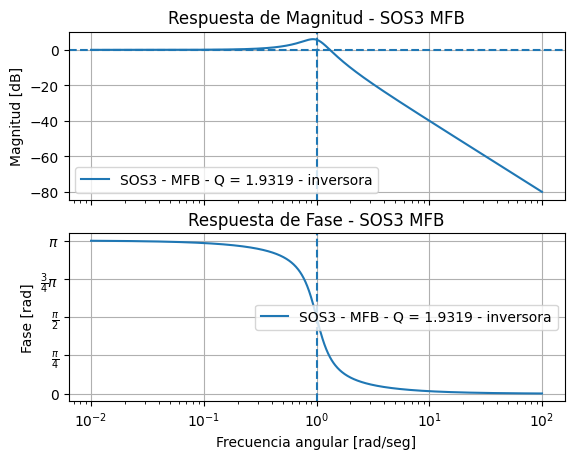

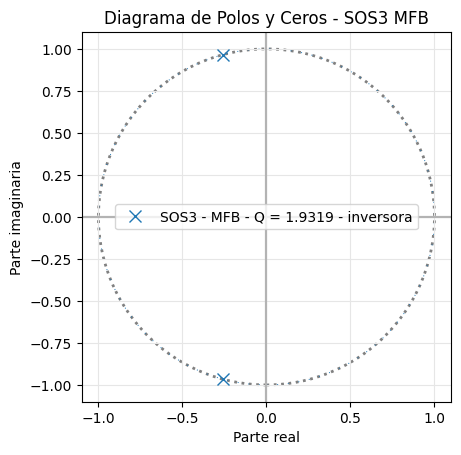

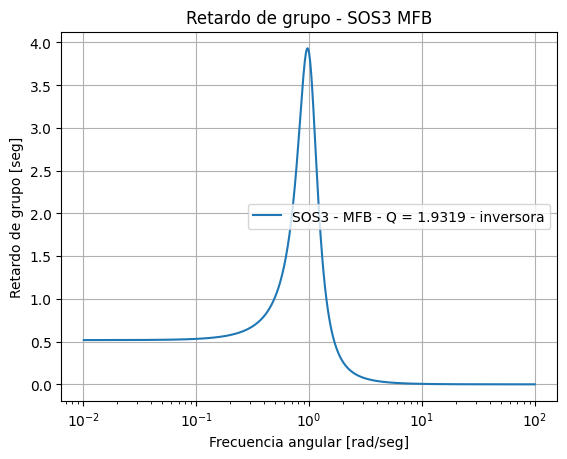

In [16]:
# ------------------------------------------------------------
# SOS3 - MFB
#
# T_SOS3(s) = -1 / (s^2 + 0.5176s + 1)
# Q3 = 1 / 0.5176 = 1.9319
# ------------------------------------------------------------

num_sos3 = [-1]
den_sos3 = [1, 0.5176, 1]

sos3_tf = TransferFunction(num_sos3, den_sos3)

bodePlot(sos3_tf, fig_id=7, filter_description='SOS3 - MFB - Q = 1.9319 - inversora')

fig7 = plt.figure(7)
axs7 = fig7.axes

axs7[0].set_title('Respuesta de Magnitud - SOS3 MFB')
axs7[1].set_title('Respuesta de Fase - SOS3 MFB')
axs7[0].set_ylabel('Magnitud [dB]')
axs7[1].set_ylabel('Fase [rad]')
axs7[1].set_xlabel('Frecuencia angular [rad/seg]')

axs7[0].axvline(1, linestyle='--')
axs7[0].axhline(0, linestyle='--')
axs7[1].axvline(1, linestyle='--')


pzmap(sos3_tf, fig_id=8, filter_description='SOS3 - MFB - Q = 1.9319 - inversora')

fig8 = plt.figure(8)
axs8 = fig8.axes

fig8._suptitle.set_text('')
axs8[0].set_title('Diagrama de Polos y Ceros - SOS3 MFB')
axs8[0].set_xlabel('Parte real')
axs8[0].set_ylabel('Parte imaginaria')


GroupDelay(sos3_tf, fig_id=9, filter_description='SOS3 - MFB - Q = 1.9319 - inversora')

fig9 = plt.figure(9)
axs9 = fig9.axes

axs9[0].set_title('Retardo de grupo - SOS3 MFB')
axs9[0].set_xlabel('Frecuencia angular [rad/seg]')
axs9[0].set_ylabel('Retardo de grupo [seg]')

plt.show()

## LTSpice:

### Circuito Utilizado:
<div align="center">
    <img src="./Imagenes/CircuitoLTSpice.png" alt="Circuito LPF Orden 6" width="1500"/>
</div>

#### Modulo y Fase:
1) <ins>SOS 1: Sallen Key + Divisor Resistivo:
<div align="center">
    <img src="./Imagenes/SOS1.png" alt="Sallen Key + Divisor Resistivo" width="1500"/>
</div>

2) <ins>SOS 2: KHN
<div align="center">
    <img src="./Imagenes/SOS2.png" alt="KHN" width="1500"/>
</div>

3) <ins>SOS 3: MFB
<div align="center">
    <img src="./Imagenes/SOS3.png" alt="MFB" width="1500"/>
</div>

4) <ins> LPF Orden 6:
<div align="center">
    <img src="./Imagenes/Orden6.png" alt="Orden6" width="1500"/>
</div>

<ins> Pendiente de Orden 6:
<div align="center">
    <img src="./Imagenes/Pendiente -120db.png" alt="Pendiente -120db" width="500"/>
</div>

#### Comparación:
<div align="center">
    <img src="./Imagenes/Comparacion.png" alt="Pendiente -120db" width="1500"/>
</div>


## Ejercicio 4: 10db
### Circuito:
<div align="center">
    <img src="./Imagenes/Ej4.png" alt="CtoEj4" width="1500"/>
</div>

### Modulo y Fase:

<div align="center">
    <img src="./Imagenes/Ej4ModFase.png" alt="Modulo y Fase Ej4" width="1500"/>
</div>

## Bonus: Butterworth pasa bajos de orden 7

Para el caso bonus se analiza un filtro Butterworth pasa bajos de orden 7. La transferencia normalizada puede escribirse como:

$$
\boxed{
T_{LPF7}(s)=
\dfrac{1}
{(s+1)(s^2+0,4450s+1)(s^2+1,2470s+1)(s^2+1,8020s+1)}
}
$$

Sin embargo, el diseño no consiste únicamente en agregar esta sección al filtro de orden 6. Al aumentar el orden del filtro, cambia la distribución completa de polos del Butterworth, por lo que también cambian los coeficientes de las secciones de segundo orden y sus factores de calidad.

Por este motivo, fue necesario recalcular todas las secciones para obtener los nuevos valores:

$$
Q_1=0,5549
$$

$$
Q_2=0,8019
$$

$$
Q_3=2,2472
$$

### Asignación de secciones

La implementación se realiza en orden creciente de $Q$, utilizando las mismas configuraciones que en el caso de orden 6:

| Sección | Configuración | Factor asociado | $Q$ |
|---|---|---|---|
| Primer orden | RC pasa bajos | $s+1$ | - |
| SOS 1 | Sallen-Key | $s^2+1,8020s+1$ | $0,5549$ |
| SOS 2 | KHN | $s^2+1,2470s+1$ | $0,8019$ |
| SOS 3 | MFB | $s^2+0,4450s+1$ | $2,2472$ |

Entonces:

$$
T_{LPF7}(s)=
\dfrac{1}{s+1}
\cdot
\dfrac{1}{s^2+1,8020s+1}
\cdot
\dfrac{1}{s^2+1,2470s+1}
\cdot
\dfrac{1}{s^2+0,4450s+1}
$$

### <ins>SOS 1: Sallen-Key

Para la primera sección de segundo orden se utiliza una red Sallen-Key. El factor a implementar es:

$$
s^2+1,8020s+1
$$

Comparando con:

$$
s^2+\dfrac{1}{Q}s+1
$$

se obtiene:

$$
Q=0,5549
$$

Para la red Sallen-Key normalizada se tenía:

$$
T_{SOS1}(s)=K\dfrac{1}{s^2+s(3-K)+1}
$$

Por comparación:

$$
3-K=\dfrac{1}{Q}
$$

Entonces:

$$
K=3-\dfrac{1}{Q}
$$

Reemplazando:

$$
K=3-\dfrac{1}{0,5549}
$$

$$
K=3-1,8020
$$

$$
\boxed{K=1,198}
$$

La ganancia se implementa mediante:

$$
K=1+\dfrac{R_4}{R_3}
$$

Entonces:

$$
\dfrac{R_4}{R_3}=K-1
$$

$$
\dfrac{R_4}{R_3}=1,198-1
$$

$$
\boxed{\dfrac{R_4}{R_3}=0,198}
$$

Adoptando:

$$
\boxed{R_3=1}
$$

se obtiene:

$$
\boxed{R_4=0,198}
$$

### Divisor resistivo de compensación

La sección Sallen-Key introduce una ganancia:

$$
K=1,198
$$

Como la transferencia Butterworth normalizada debe conservar ganancia unitaria, se agrega un divisor resistivo que compense dicha ganancia.

La atenuación necesaria es:

$$
A=\dfrac{1}{K}
$$

$$
A=\dfrac{1}{1,198}
$$

$$
\boxed{A=0,8347}
$$

Para un divisor resistivo:

$$
A=\dfrac{R_b}{R_a+R_b}
$$

Adoptando:

$$
\boxed{R_b=1}
$$

se despeja:

$$
R_a=R_b\dfrac{1-A}{A}
$$

$$
R_a=\dfrac{1-0,8347}{0,8347}
$$

$$
\boxed{R_a=0,198}
$$

Por lo tanto, el divisor resistivo queda:

$$
\boxed{R_a=0,198}
$$

$$
\boxed{R_b=1}
$$

### <ins> SOS 2: KHN

Para la segunda sección de segundo orden se utiliza una red KHN. El factor a implementar es:

$$
s^2+1,2470s+1
$$

Comparando con:

$$
s^2+\dfrac{1}{Q}s+1
$$

se obtiene:

$$
Q=0,8019
$$

Para la red KHN normalizada:

$$
T_{SOS2}(s)=
-\dfrac{1}{s^2+s\dfrac{3}{K}+1}
$$

Por comparación:

$$
\dfrac{1}{Q}=\dfrac{3}{K}
$$

Entonces:

$$
Q=\dfrac{K}{3}
$$

La relación resistiva de la red es:

$$
K=1+\dfrac{R_6}{R_7}
$$

Por lo tanto:

$$
Q=\dfrac{1}{3}\left(1+\dfrac{R_6}{R_7}\right)
$$

Adoptando:

$$
\boxed{R_7=1}
$$

queda:

$$
Q=\dfrac{R_6+1}{3}
$$

Despejando:

$$
R_6=3Q-1
$$

Reemplazando:

$$
R_6=3\cdot0,8019-1
$$

$$
R_6=2,4057-1
$$

$$
\boxed{R_6=1,4057}
$$

### <ins> SOS 3: MFB

Para la tercera sección de segundo orden se utiliza una red MFB, ya que debe implementar el mayor valor de $Q$:

$$
Q=2,2472
$$

El factor correspondiente es:

$$
s^2+0,4450s+1
$$

Para la red MFB, si se adoptan resistencias iguales:

$$
R_1=R_2=R_3=R
$$

pero capacitores distintos:

$$
C_1\neq C_2
$$

el factor de calidad queda:

$$
Q=\dfrac{1}{3}\sqrt{\dfrac{C_1}{C_2}}
$$

Despejando:

$$
3Q=\sqrt{\dfrac{C_1}{C_2}}
$$

$$
\dfrac{C_1}{C_2}=9Q^2
$$

Reemplazando:

$$
\dfrac{C_1}{C_2}=9(2,2472)^2
$$

$$
\boxed{\dfrac{C_1}{C_2}=45,45}
$$

Por lo tanto:

$$
C_1=45,45C_2
$$

Además, como se trabaja normalizado:

$$
\omega_0=1
$$

y para la MFB:

$$
\omega_0^2=\dfrac{1}{R^2C_1C_2}
$$

Adoptando:

$$
R=1
$$

queda:

$$
C_1C_2=1
$$

Se tienen entonces las condiciones:

$$
\dfrac{C_1}{C_2}=45,45
$$

$$
C_1C_2=1
$$

De la primera:

$$
C_1=45,45C_2
$$

Reemplazando en la segunda:

$$
45,45C_2^2=1
$$

$$
C_2=\sqrt{\dfrac{1}{45,45}}
$$

$$
\boxed{C_2=0,1483}
$$

Luego:

$$
C_1=45,45\cdot0,1483
$$

$$
\boxed{C_1=6,7416}
$$

Por lo tanto, los valores normalizados para la MFB son:

$$
\boxed{R_1=R_2=R_3=1}
$$

$$
\boxed{C_1=6,7416}
$$

$$
\boxed{C_2=0,1483}
$$

---


### Respuesta en módulo esperada

Para un filtro Butterworth pasa bajos de orden 7 normalizado:

$$
|T(j\omega)|^2=\dfrac{1}{1+\omega^{14}}
$$

Por lo tanto:

$$
|T(j\omega)|=\dfrac{1}{\sqrt{1+\omega^{14}}}
$$

En baja frecuencia:

$$
\omega=0
$$

$$
\boxed{|T(j0)|=1}
$$

$$
|T(j0)|_{dB}=0\ \text{dB}
$$

En la frecuencia de corte:

$$
\omega=1
$$

$$
|T(j1)|=\dfrac{1}{\sqrt{2}}
$$

$$
\boxed{|T(j1)|_{dB}=-3\ \text{dB}}
$$

En alta frecuencia:

$$
\omega\rightarrow\infty
$$

$$
|T(j\omega)|\approx\dfrac{1}{\omega^7}
$$

Pasando a decibeles:

$$
|T(j\omega)|_{dB}
=
20\log_{10}\left(\dfrac{1}{\omega^7}\right)
$$

$$
\boxed{
|T(j\omega)|_{dB}
=
-140\log_{10}(\omega)
}
$$

Por lo tanto, la pendiente final esperada es:

$$
\boxed{-140\ \text{dB/dec}}
$$


<div align="center">
    <img src="./Imagenes/ModuloOrden7.png" alt="Modulo Orden7" width="500"/>
</div>

---


### Respuesta de fase esperada

Para calcular la fase se evalúa la transferencia en:

$$
s=j\omega
$$

La transferencia del Butterworth de orden 7 es:

$$
T_{LPF7}(s)=
\dfrac{1}
{(s+1)(s^2+1,8020s+1)(s^2+1,2470s+1)(s^2+0,4450s+1)}
$$

Reemplazando $s=j\omega$:

$$
T_{LPF7}(j\omega)=
\dfrac{1}
{(j\omega+1)((j\omega)^2+1,8020j\omega+1)((j\omega)^2+1,2470j\omega+1)((j\omega)^2+0,4450j\omega+1)}
$$

Como:

$$
(j\omega)^2=-\omega^2
$$

cada sección de segundo orden queda de la forma:

$$
(j\omega)^2+a(j\omega)+1
=
1-\omega^2+ja\omega
$$

Por lo tanto, los denominadores quedan:

$$
D_1(j\omega)=1+j\omega
$$

$$
D_2(j\omega)=1-\omega^2+j1,8020\omega
$$

$$
D_3(j\omega)=1-\omega^2+j1,2470\omega
$$

$$
D_4(j\omega)=1-\omega^2+j0,4450\omega
$$

La fase total de la transferencia es la fase del numerador menos la fase del denominador. Como el numerador es real positivo:

$$
\angle N(j\omega)=0
$$

Entonces:

$$
\varphi_T(\omega)=
-\left[
\angle D_1(j\omega)+
\angle D_2(j\omega)+
\angle D_3(j\omega)+
\angle D_4(j\omega)
\right]
$$

Calculando cada fase como parte imaginaria sobre parte real:

$$
\angle D_1(j\omega)=
\tan^{-1}\left(\dfrac{\omega}{1}\right)
$$

$$
\angle D_2(j\omega)=
\tan^{-1}\left(\dfrac{1,8020\omega}{1-\omega^2}\right)
$$

$$
\angle D_3(j\omega)=
\tan^{-1}\left(\dfrac{1,2470\omega}{1-\omega^2}\right)
$$

$$
\angle D_4(j\omega)=
\tan^{-1}\left(\dfrac{0,4450\omega}{1-\omega^2}\right)
$$

Por lo tanto, la fase total resulta:

$$
\boxed{
\varphi_T(\omega)=
-\left[
\tan^{-1}(\omega)
+
\tan^{-1}\left(\dfrac{1,8020\omega}{1-\omega^2}\right)
+
\tan^{-1}\left(\dfrac{1,2470\omega}{1-\omega^2}\right)
+
\tan^{-1}\left(\dfrac{0,4450\omega}{1-\omega^2}\right)
\right]
}
$$

Para baja frecuencia:

$$
\omega \rightarrow 0
$$

$$
\varphi_T(0)=0
$$

Para alta frecuencia:

$$
\omega \rightarrow \infty
$$

la sección de primer orden aporta:

$$
-90^\circ
$$

y cada sección de segundo orden aporta:

$$
-180^\circ
$$

Como hay tres secciones de segundo orden:

$$
\varphi_T(\infty)=-90^\circ+3(-180^\circ)
$$

$$
\boxed{\varphi_T(\infty)=-630^\circ}
$$

En radianes:

$$
\boxed{\varphi_T(\infty)=-\dfrac{7\pi}{2}}
$$


<div align="center">
    <img src="./Imagenes/FaseOrden7.png" alt="Fase Orden7" width="500"/>
</div>

---

### Diagrama de polos y ceros

La transferencia del filtro Butterworth de orden 7 no posee ceros finitos, ya que el numerador es constante:

$$
N(s)=1
$$

Por lo tanto:

$$
z_i=\varnothing
$$

Los polos se ubican sobre una circunferencia unitaria en el semiplano izquierdo. Para el filtro de orden 7, se tiene un polo real y tres pares de polos complejos conjugados:

$$
p_1=-1
$$

$$
p_{2,3}=-0,222\pm j0,975
$$

$$
p_{4,5}=-0,624\pm j0,782
$$

$$
p_{6,7}=-0,901\pm j0,434
$$

Todos los polos tienen parte real negativa, por lo que el sistema es estable.


<div align="center">
    <img src="./Imagenes/PolosOrden7.png" alt="Polos Orden7" width="500"/>
</div>

---


### <ins>Verificacíon por Simulación:

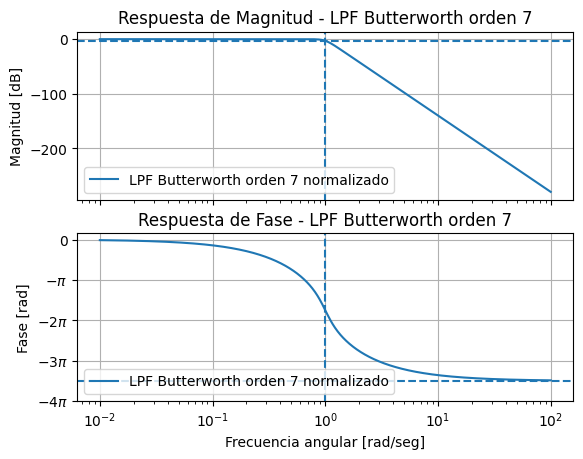

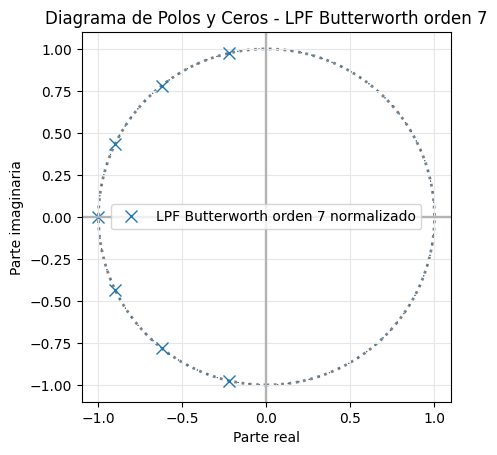

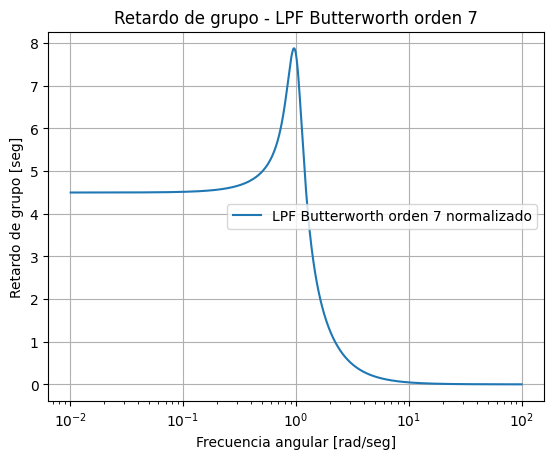

Verificaciones:
w =      0 rad/s
  |T(jw)|     = 1.000000
  |T(jw)| dB  = 0.000 dB
  fase        = 0.000000 rad

w =      1 rad/s
  |T(jw)|     = 0.707137
  |T(jw)| dB  = -3.010 dB
  fase        = 0.785398 rad

w =     10 rad/s
  |T(jw)|     = 0.000000
  |T(jw)| dB  = -140.000 dB
  fase        = 2.020733 rad

w =    100 rad/s
  |T(jw)|     = 0.000000
  |T(jw)| dB  = -280.000 dB
  fase        = 1.615737 rad

Denominador total:
[ 1.          4.494      10.097899   14.59185583 14.59185583 10.097899
  4.494       1.        ]

Polos:
(-0.22250000000000103+0.9749326899842842j)
(-0.22250000000000103-0.9749326899842842j)
(-0.6234999999999912+0.7818233496129549j)
(-0.6234999999999912-0.7818233496129549j)
(-0.9999999999999718+0j)
(-0.9010000000000258+0.4338190867170112j)
(-0.9010000000000258-0.4338190867170112j)


In [23]:
# ------------------------------------------------------------
# Transferencia Butterworth pasa bajos normalizada de orden 7
#
# T_LPF7(s) = 1 / [(s + 1)
#                  (s^2 + 0.4450s + 1)
#                  (s^2 + 1.2470s + 1)
#                  (s^2 + 1.8020s + 1)]
# ------------------------------------------------------------

# ------------------------------------------------------------
# Denominadores de cada sección
# ------------------------------------------------------------

# Sección de primer orden
den_orden1 = [1, 1]              # s + 1

# Secciones de segundo orden
den_sos1 = [1, 1.8020, 1]        # SOS 1: Q = 0.5549
den_sos2 = [1, 1.2470, 1]        # SOS 2: Q = 0.8019
den_sos3 = [1, 0.4450, 1]        # SOS 3: Q = 2.2472

# ------------------------------------------------------------
# Denominador total del filtro
# ------------------------------------------------------------

den_total = np.polymul(den_orden1, den_sos1)
den_total = np.polymul(den_total, den_sos2)
den_total = np.polymul(den_total, den_sos3)

# Numerador total
num_total = [1]

# Función transferencia total
my_tf = TransferFunction(num_total, den_total)

# ------------------------------------------------------------
# Respuesta de Magnitud y Fase
# ------------------------------------------------------------

bodePlot(my_tf, fig_id=1, filter_description='LPF Butterworth orden 7 normalizado')

fig1 = plt.figure(1)
axs1 = fig1.axes

axs1[0].set_title('Respuesta de Magnitud - LPF Butterworth orden 7')
axs1[1].set_title('Respuesta de Fase - LPF Butterworth orden 7')

axs1[0].set_ylabel('Magnitud [dB]')
axs1[1].set_ylabel('Fase [rad]')
axs1[1].set_xlabel('Frecuencia angular [rad/seg]')

# Líneas de referencia en módulo
axs1[0].axvline(1, linestyle='--', label=r'$\omega_0=1$')
axs1[0].axhline(-3, linestyle='--', label='-3 dB')

# Líneas de referencia en fase
axs1[1].axvline(1, linestyle='--', label=r'$\omega_0=1$')
axs1[1].axhline(-7*np.pi/2, linestyle='--', label=r'$-\frac{7\pi}{2}$ rad')

# ------------------------------------------------------------
# Diagrama de Polos y Ceros
# ------------------------------------------------------------

pzmap(my_tf, fig_id=2, filter_description='LPF Butterworth orden 7 normalizado')

fig2 = plt.figure(2)
axs2 = fig2.axes

fig2._suptitle.set_text('')
axs2[0].set_title('Diagrama de Polos y Ceros - LPF Butterworth orden 7')
axs2[0].set_xlabel('Parte real')
axs2[0].set_ylabel('Parte imaginaria')

# ------------------------------------------------------------
# Retardo de Grupo
# ------------------------------------------------------------

GroupDelay(my_tf, fig_id=3, filter_description='LPF Butterworth orden 7 normalizado')

fig3 = plt.figure(3)
axs3 = fig3.axes

axs3[0].set_title('Retardo de grupo - LPF Butterworth orden 7')
axs3[0].set_xlabel('Frecuencia angular [rad/seg]')
axs3[0].set_ylabel('Retardo de grupo [seg]')

plt.show()

# ------------------------------------------------------------
# Verificaciones numéricas puntuales
# ------------------------------------------------------------

# Evaluar en w = 0, w = 1 y frecuencias grandes
w_test = np.array([0, 1, 10, 100])

_, H_test = signal.freqs(num_total, den_total, w_test)

print("Verificaciones:")
for wi, Hi in zip(w_test, H_test):
    print(f"w = {wi:>6} rad/s")
    print(f"  |T(jw)|     = {abs(Hi):.6f}")
    print(f"  |T(jw)| dB  = {20*np.log10(abs(Hi)):.3f} dB")
    print(f"  fase        = {np.angle(Hi):.6f} rad")
    print()

# ------------------------------------------------------------
# Denominador y polos
# ------------------------------------------------------------

polos = np.roots(den_total)

print("Denominador total:")
print(den_total)

print("\nPolos:")
for p in polos:
    print(p)

## LTSpice:
### <ins>Circuito: 

<div align="center">
    <img src="./Imagenes/Orden7_Circuito.png" alt="Orden7_Circuito" width="1500"/>
</div>


### <ins>Modulo y Fase: 

<div align="center">
    <img src="./Imagenes/ModuloFaseOrden7.png" alt="Modulo y Fase Orden7" width="1500"/>
</div>

#### <ins>Pendiente:

<div align="center">
    <img src="./Imagenes/Orden7Pendiente.png" alt="Pendiente Orden7" width="500"/>
</div>

---
---

# Resolución a mano:

## <ins>TS2:

In [25]:
from IPython.display import IFrame
IFrame("Imagenes/TS2.pdf", width=1000, height=700)

## <ins>Análisis de OpAmps:

In [26]:
from IPython.display import IFrame
IFrame("Imagenes/Analisis_OpAmps_PasaBajos.pdf", width=1000, height=700)